In [150]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import pandas as pd 
import seaborn as sns 
import sklearn

In [151]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
  
  
# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)
     

In [152]:
link = "https://drive.google.com/file/d/1q3TlIBXha77_ACWYsi9PB_ziaJvQ6oG4/view?usp=sharing"

id = link.split("/")[-2]
  
downloaded = drive.CreateFile({"id":id}) 
downloaded.GetContentFile("train.csv")  
  
df = pd.read_csv("train.csv")
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


In [153]:
df.drop('id', axis=1, inplace=True)
df.dropna(axis=0, inplace=True)
Gender = {'Male':0, 
        'Female':1}

CustomerType= {'Loyal Customer':0,
               'disloyal Customer':1}

TypeofTravel= {'Business travel':0,
               'Personal Travel':1}

Class= {'Business':0,
        'Eco':1,
        'Eco Plus':2}

satisfaction= {'neutral or dissatisfied':0,
               'satisfied':1}

df['Gender'] = df['Gender'].map(Gender)
df['Customer Type'] = df['Customer Type'].map(CustomerType)
df['Type of Travel'] = df['Type of Travel'].map(TypeofTravel)
df['Class'] = df['Class'].map(Class)
df['satisfaction'] = df['satisfaction'].map(satisfaction)

In [154]:
X = df.iloc[:, 0:23].values 
Y = df.iloc[:,23].values
X = pd.DataFrame(X)
Y = pd.DataFrame(Y)

In [155]:
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import seaborn as sns  
sc = StandardScaler()
X_train_std = sc.fit_transform(X)

In [156]:
scaled_data_train = pd.DataFrame(X_train_std)

In [157]:
cov_mat = np.cov(X_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

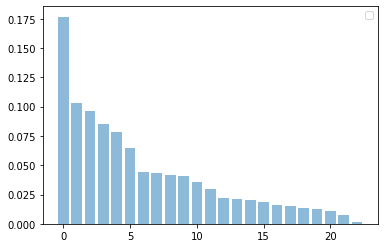

In [158]:
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
plt.bar(range(0,23), var_exp, alpha=0.5,
        align='center')
plt.legend(loc='best')
plt.show()

In [159]:
pca_train = PCA(n_components = 12)
pca_train.fit(scaled_data_train)
data_pca_X_train = pca_train.transform(scaled_data_train)
data_pca_X_train = pd.DataFrame(data_pca_X_train)

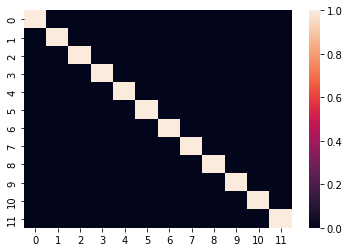

In [160]:
sns.heatmap(data_pca_X_train.corr())

In [161]:
from sklearn.model_selection import train_test_split
N_train = int(len(data_pca_X_train) * 0.8)
N_test = len(data_pca_X_train) - N_train
X_train, X_test, Y_train, Y_test = train_test_split(data_pca_X_train, Y, 
                                                    train_size = N_train, test_size = N_test, 
                                                    stratify = Y, random_state = 15)

In [162]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 10)
knn.fit(X_train, Y_train)

/usr/local/lib/python3.8/dist-packages/sklearn/neighbors/_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=10)

In [163]:
y_test_predict = knn.predict(X_test)
err_train = 1 - knn.score(X_train, Y_train)
err_test = 1 - knn.score(X_test, Y_test)
print('Ошибка на обучении: ' + str(err_train * 100) + '%')
print('Ошибка на тесте: ' + str(err_test * 100) + '%')

Ошибка на обучении: 7.545098039215681%
Ошибка на тесте: 8.885563975095323%


Из этого можно сделать вывод, что при понижении размерности в данном датаесте, ошибка возрастает. В данном случае найден лучший вариант, когда ошибка не такая большая. 
То есть чтобы более точно предсказывать значения "satisfaction", необходимо использовать все признаки датасета.